### Summary:
In this notebook I'll prepare inputs for cell type proportion associations using data from three different single cell islet studies. I'll be training linear models to predict the proportion of a cell type across samples based on a variety of metadata features (including study of origin). Here I'll collect all the per-donor proportions and per-donor metadata for 3 studies. 

In [1]:
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))

suppressMessages(library(tidyverse))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(Matrix))

suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr))
suppressMessages(library(RColorBrewer))

# Set up

In [2]:
overall_outdir <- '/dir/to/write/outputs/to'
outdir <- file.path(overall_outdir,'celltype_props','inputs')

In [3]:
celltypes <- c('beta', 'alpha', 'delta', 'gamma', 'acinar',
               'ductal', 'endothelial', 'immune', 'stellate')

celltype_colors = c('acinar'='#09850B', 'alpha'='#F51646', 'beta'='#3F98E0',
                    'delta'='#FFA946', 'ductal'='#F5DE6C', 'endothelial'='#752BBA', 
                    'gamma'='#A1D99B', 'immune'='#F598C9', 'stellate'='#AB7345')

In [4]:
options(repr.plot.width=5, repr.plot.height=5)

# Collect information on number of cells per cell type for each donor

### Run this for each dataset separately

In [ ]:
# Read in the final Seurat object
indir <- "/dir/with/final/object"
rds_fp <- file.path(indir,"final_object.rds")
tic()
adata <- readRDS(rds_fp)
toc()

In [ ]:
# Calculate proportion of each celltype across samples
ct_counts <- list()

for (sample in samples){
    sample_matrix <- adata@meta.data[adata$library == sample,]
    props <- c()
    for (celltype in celltypes){
        prop_ct <- sum(sample_matrix$major_celltypes_fin == celltype)/dim(sample_matrix)[1]
        props <- c(props, prop_ct)
    }
    ct_counts[[sample]] <- props
}

# Reformat results and add onto meta df
props_df <- data.frame(t(as.data.frame(ct_counts)))
colnames(props_df) <- paste(celltypes, '_total_prop',sep='')
head(props_df)

In [ ]:
# scale counts
props_df_scaled <- sqrt(props_df)
colnames(props_df_scaled) <- paste0(colnames(props_df), '_sqrt')
props <- cbind(props_df,props_df_scaled)
head(props)

In [ ]:
# Write to file
prop_fp <- file.path(outdir, 'Celltype_donor_prop_wsqrt.txt')
write.table(props, prop_fp, sep='\t', quote=FALSE)

### Then merge this into one dataframe with all donors from all studies

# Plot distribution of data

### Scaled proportion values across cell types (shaded by dataset)

In [ ]:
meta_fp <- '/path/to/final/df/with/props'
total_meta <- read.table(meta_fp, sep='\t', header=1)

In [68]:
meta_fin <- subset(total_meta, dataset %in% c('Alberta','HPAP','Wang')) %>%
            subset(dataset!='Wang' | assays!='Multiome')
# meta_fin

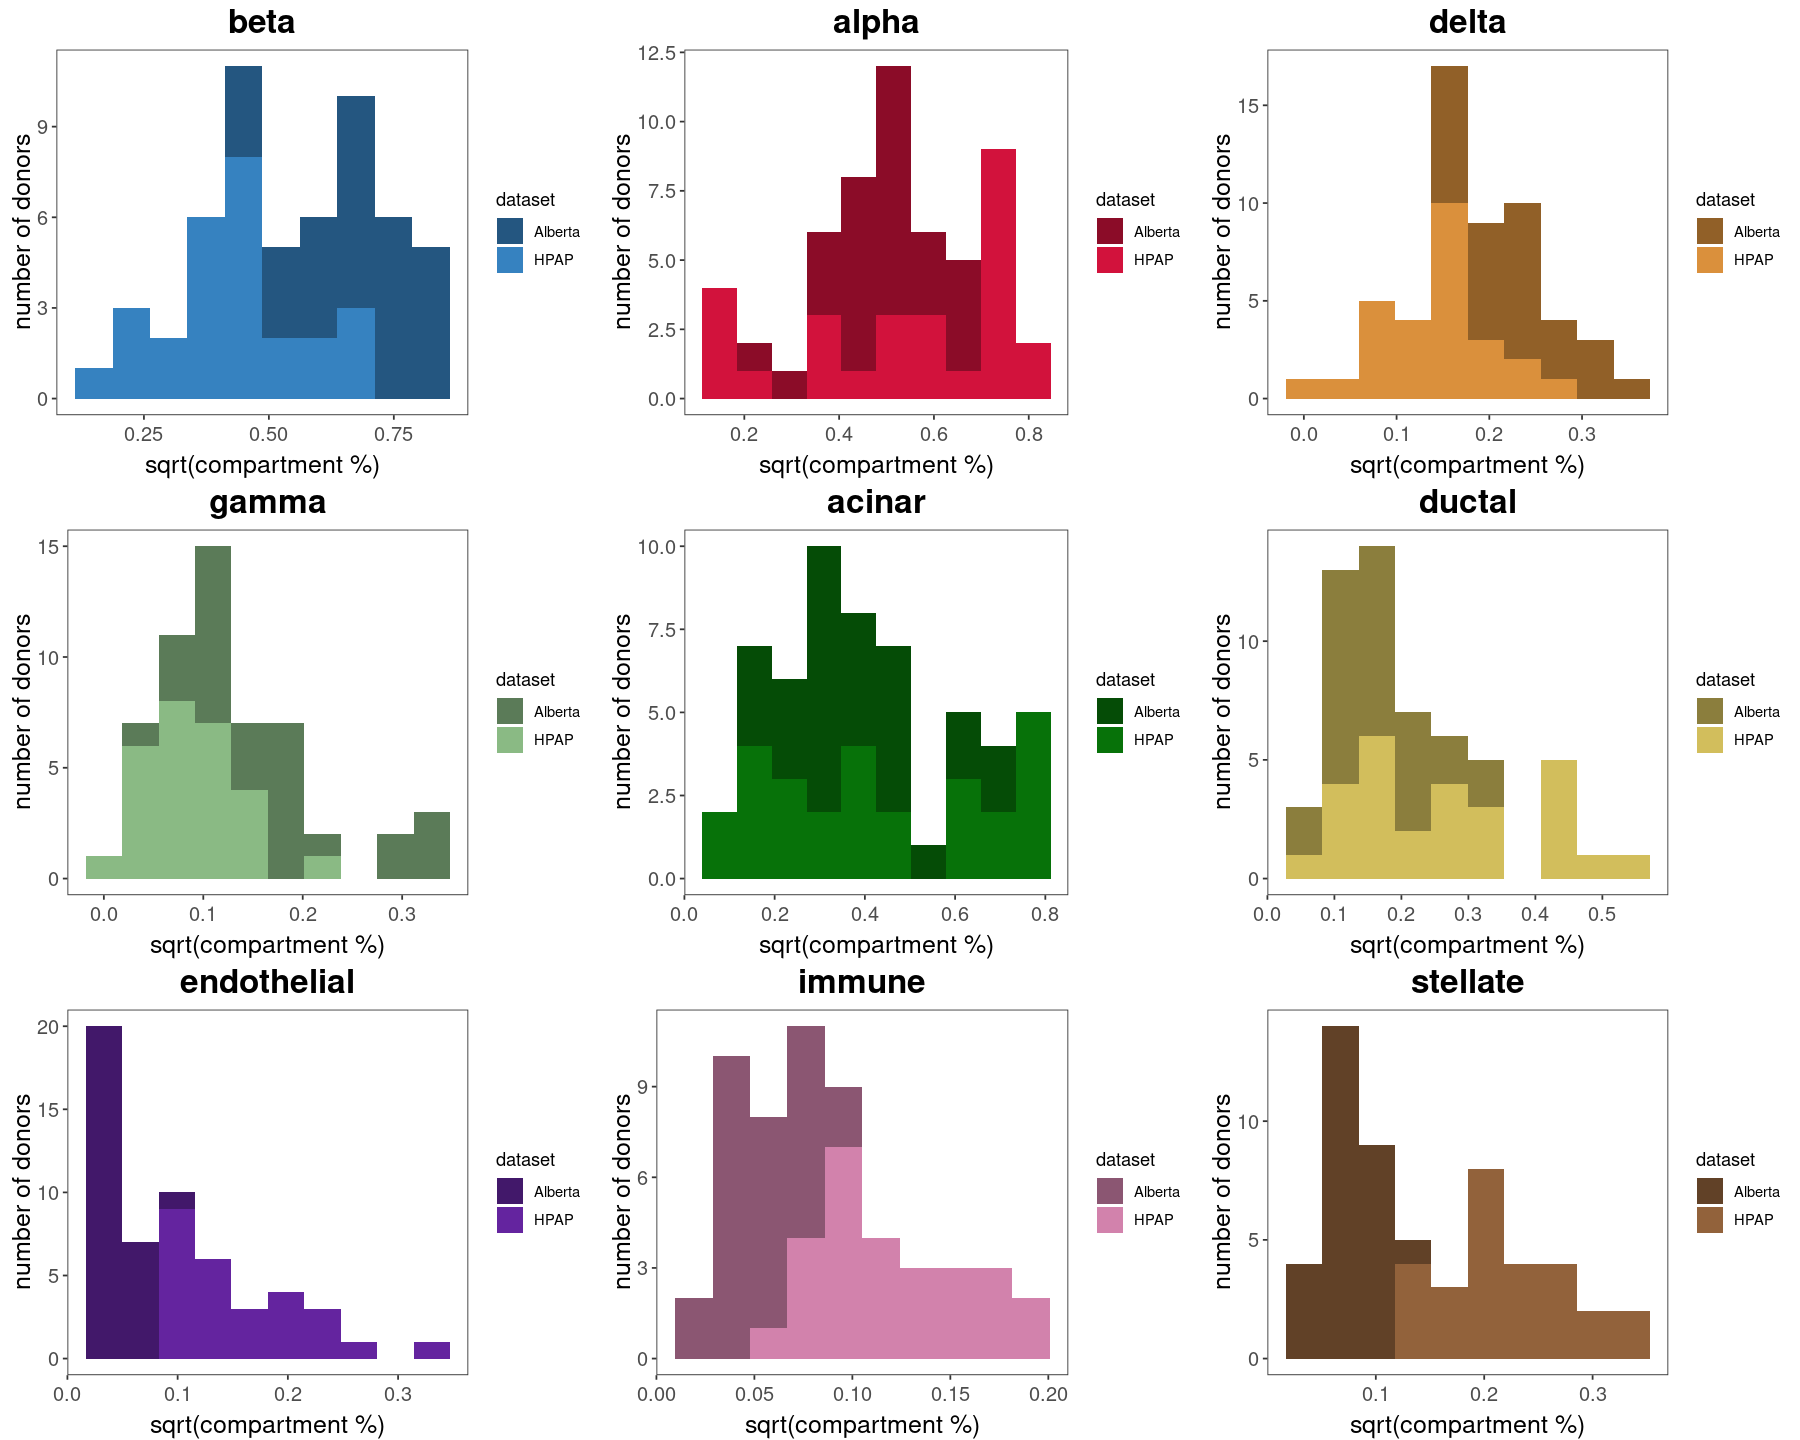

In [73]:
plots <- list()   
theme_set(theme_bw())

for (celltype in celltypes){
    # collect data and reformat
    data <- as.data.frame(fin_props_rna[,c('sample',paste0(celltype,'_cells_rna_prop_sqrt'))]) %>% subset(sample %in% meta_fin$sample)
    colnames(data)[2] <- 'counts'
    data$dataset <- suppressMessages(plyr::mapvalues(data$sample, from=meta_fin$sample, to=meta_fin$dataset))

    # make color palette
    colors <- colorRampPalette(c('black',celltype_colors[[celltype]],"white"))(8)[seq(3,6)]
    names(colors) <- c('Alberta','HPAP','Qadir','Wang')
    
    p1 <- ggplot(data, aes(x=counts, fill=dataset)) + 
            geom_histogram(bins=10) + 
            scale_fill_manual(values=colors) + 
            labs(x = 'sqrt(compartment %)', y='number of donors', title = celltype) + 
            theme(axis.text.x=element_text(size=12, vjust=0.5),
                  axis.text.y=element_text(size=12, vjust=0.5),
                  axis.title.x = element_text(size=15, vjust=-0.35),
                  axis.title.y = element_text(size=15, vjust=0.5),
                  plot.title = element_text(size=20, hjust=0.5, face="bold"),
                  panel.grid.major = element_blank(), 
                  panel.grid.minor = element_blank())
    plots[[celltype]] <- p1
}

options(repr.plot.width=15, repr.plot.height=12)
ggarrange(plotlist=plots, nrow = 3, ncol=3)

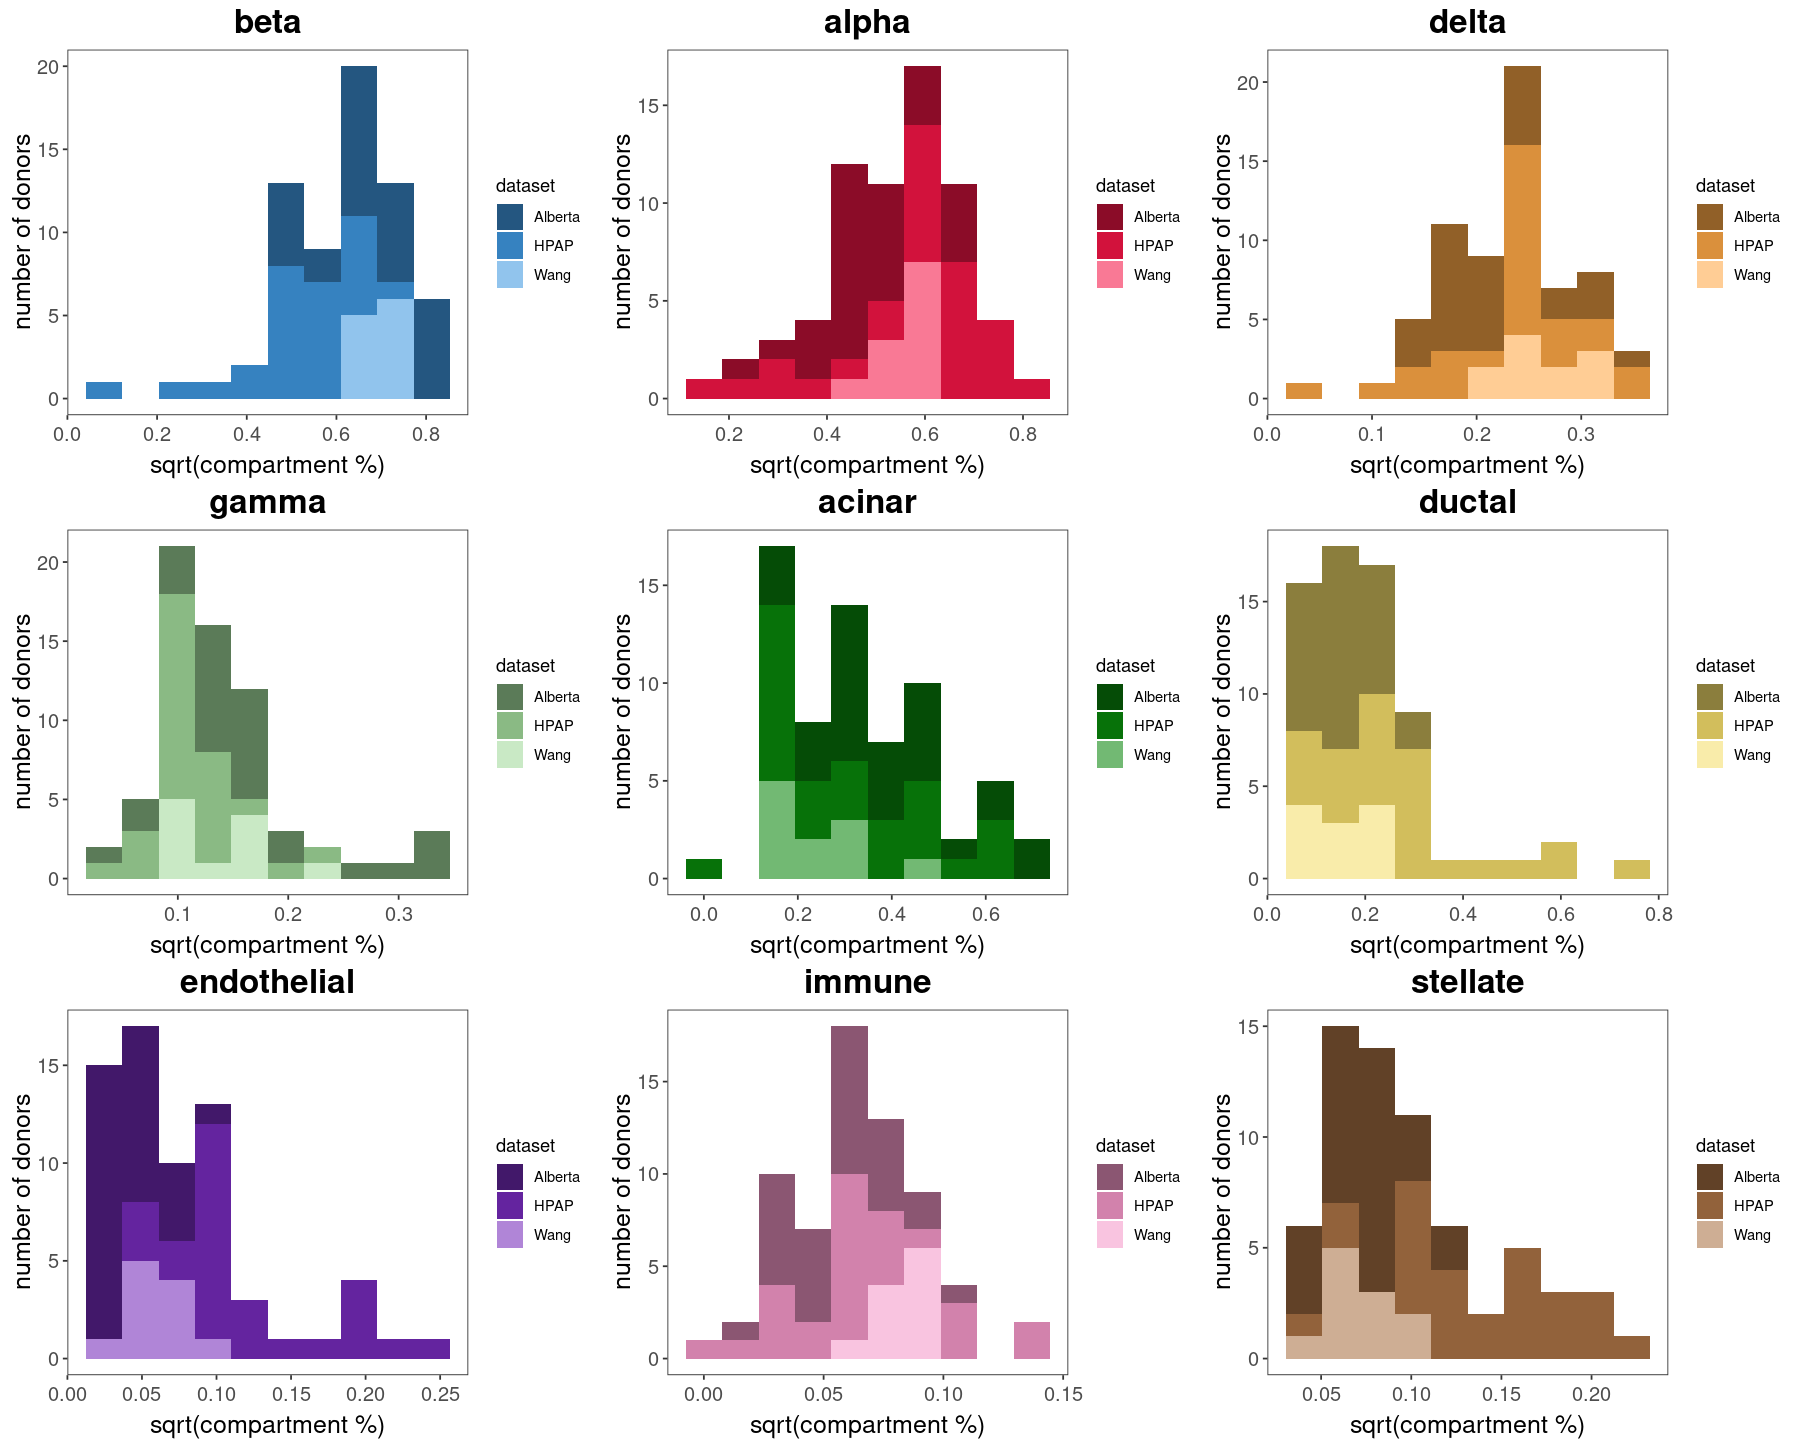

In [74]:
plots <- list()   
theme_set(theme_bw())

for (celltype in celltypes){
    # collect data and reformat
    data <- as.data.frame(fin_props_atac[,c('sample',paste0(celltype,'_cells_atac_prop_sqrt'))]) %>% subset(sample %in% meta_fin$sample)
    colnames(data)[2] <- 'counts'
    data$dataset <- suppressMessages(plyr::mapvalues(data$sample, from=meta_fin$sample, to=meta_fin$dataset))

    # make color palette
    colors <- colorRampPalette(c('black',celltype_colors[[celltype]],"white"))(8)[seq(3,6)]
    names(colors) <- c('Alberta','HPAP','Qadir','Wang')
    
    p1 <- ggplot(data, aes(x=counts, fill=dataset)) + 
            geom_histogram(bins=10) + 
            scale_fill_manual(values=colors) + 
            labs(x = 'sqrt(compartment %)', y='number of donors', title = celltype) + 
            theme(axis.text.x=element_text(size=12, vjust=0.5),
                  axis.text.y=element_text(size=12, vjust=0.5),
                  axis.title.x = element_text(size=15, vjust=-0.35),
                  axis.title.y = element_text(size=15, vjust=0.5),
                  plot.title = element_text(size=20, hjust=0.5, face="bold"),
                  panel.grid.major = element_blank(), 
                  panel.grid.minor = element_blank())
    plots[[celltype]] <- p1
}

options(repr.plot.width=15, repr.plot.height=12)
ggarrange(plotlist=plots, nrow = 3, ncol=3)

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] RColorBrewer_1.1-3 ggpubr_0.5.0       Matrix_1.5-1       data.table_1.14.8 
 [5] forcats_0.5.2      stringr_1.4.1      dplyr_1.0.10       purrr_0.3.5       
 [9] readr_2.1.1        tidyr_1.2.1        tibble_3.1.8       ggplot2_3.4.4     
[13] tidyverse_1.3.2    S